---
title: "Tutorial 5 (Advanced): Linking Brain to Phenotypes (Part 2: Correlation/Regression)"
authors:
  - name: Sapolnach Prompiengchai
    affiliations:
      - University of Oxford
  - name: Aarushi Vardhan
    affiliations:
      - University of Toronto / University of Cambridge
---



In [ ]:
# Imports and project paths

from pathlib import Path
import sys
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import shapiro, levene, ttest_ind, kendalltau
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm


# Option 1: use the current working directory if the notebook lives inside the project folder
# PROJECT_DIR = Path.cwd()

# Option 2: manually specify your project directory if needed
PROJECT_DIR = Path("/Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026")
sys.path.append(str(PROJECT_DIR)) # adds project directory to the \ Python path

RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

fc_stack_path = RESULTS_DIR / "subject_fc_stack.npy"
subject_ids_path = RESULTS_DIR / "subject_ids.npy"
region_names_path = RESULTS_DIR / "region_names.npy"
mean_fc_path = RESULTS_DIR / "mean_fc.npy"

# Behavioural / metadata directory
BEHAV_DIR = Path("/Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/data/Behavioural_Data_MPILMBB_LEMON")
meta_path = BEHAV_DIR / "META_File_IDs_Age_Gender_Education_Drug_Smoke_SKID_LEMON.csv" # contains age information

# Processed data from tutorials
processed_dir = PROJECT_DIR / "processed_data"

# Import functions from our previous tutorials
from functions.connectivity import (fisher_z_transform, get_overall_fc, get_network_pair_fc)

In [124]:
# Load FC matrix and overall connectivity + cleaned metadata

fc_stack = np.load(fc_stack_path)  # shape: (n_subjects, n_nodes, n_nodes)
subject_ids = np.load(subject_ids_path, allow_pickle=True).astype(str)
region_names = np.load(region_names_path, allow_pickle=True).astype(str)

# Load cleaned participant metadata
analysis_meta = pd.read_csv(processed_dir / "lemon_analysis_metadata.csv")

# Load network-to-index mapping
net_to_idx = np.load(processed_dir / "network_region_indices.npy", allow_pickle=True).item()

# Load FC summary measures
summary_df = pd.read_csv(processed_dir / "lemon_fc_overall_connectivity.csv")

In [125]:
analysis_meta.head()

,subject_id,age_bin,age_group,sex,handedness,education,smoking_num,DRUG_0=negative_1=Positive,Hamilton_Scale,BSL23_sumscore,AUDIT,Relationship_Status
0,sub-010002,65-70,Old,Female,right,Realschule,3.0,0.0,0.0,NaN,2.0,No
1,sub-010003,20-25,Young,Female,right,Gymnasium,1.0,0.0,3.0,NaN,1.0,No
2,sub-010004,65-70,Old,Female,right,Realschule,1.0,0.0,2.0,NaN,1.0,Yes
3,sub-010005,25-30,Young,Male,right,Gymnasium,1.0,0.0,0.0,4.0,1.0,No
4,sub-010006,65-70,Old,Female,ambidextrous,Realschule,1.0,0.0,0.0,NaN,2.0,Yes


In [126]:
summary_df.head()

,subject_id,raw_within_all,raw_between_all,z_within_all,z_between_all,age_group
0,sub-010002,0.430220,0.134788,0.512496,0.146496,Old
1,sub-010003,0.522442,0.267634,0.631099,0.292061,Young
2,sub-010004,0.504333,0.260840,0.644192,0.291162,Old
3,sub-010005,0.656088,0.452117,0.865692,0.520825,Young
4,sub-010006,0.610286,0.366996,0.768811,0.415498,Old


In [127]:
net_to_idx

{np.str_('Visual'): array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 50, 51, 52, 53, 54, 55, 56, 57]),
 np.str_('SMN'): array([ 9, 10, 11, 12, 13, 14, 58, 59, 60, 61, 62, 63, 64, 65]),
 np.str_('DAN'): array([15, 16, 17, 18, 19, 20, 21, 22, 66, 67, 68, 69, 70, 71, 72]),
 np.str_('VAN'): array([23, 24, 25, 26, 27, 28, 29, 73, 74, 75, 76, 77]),
 np.str_('Limbic'): array([30, 31, 32, 78, 79]),
 np.str_('FPN'): array([33, 34, 35, 36, 80, 81, 82, 83, 84, 85, 86, 87, 88]),
 np.str_('DMN'): array([37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 89, 90, 91, 92,
        93, 94, 95, 96, 97, 98, 99])}

# Correlation: Does Age Correlate With DMN connectivity

## Overview

In the previous tutorial on **Functional Connectivity**, we learned that functional connectivity is commonly estimated using **Pearson correlation** between the fMRI time series of two brain regions.

For example, we calculated the correlation between the activity of Region A and Region B to obtain a single functional connectivity value.

Now, we will use the same statistical idea in a different way.

Instead of asking:

> **Are the time series of two brain regions correlated?**

we now ask:

> **Is a brain connectivity measure correlated with age?**

In other words, we are no longer correlating **brain with brain**, but rather **brain with behaviour**.

Correlation measures the strength and direction of a relationship between two variables.

As a reminder:

- **Correlation = +1** indicates a perfect positive relationship. As one variable increases, the other always increases.
- **Correlation = 0** indicates no consistent relationship between the variables.
- **Correlation = −1** indicates a perfect negative relationship. As one variable increases, the other always decreases.

Although different correlation methods produce slightly different statistics (for example, Pearson's *r*, Spearman's *ρ*, or Kendall's *τ*), they all aim to answer the same general question:

> **Do two variables tend to vary together?**

---

### Resting-State Networks: DMN

So far, we have examined whether **overall functional connectivity** differs with age. 

**However, we haven't yet explored whether age-related changes is associated with any specific functional networks or connectivity!**

To narrow our scope, let's look at one network that has received considerable attention in the neuroscience literature: the **Default Mode Network (DMN)**. The DMN is involved in internally directed cognitive processes such as autobiographical memory, mind-wandering, self-referential thinking, and future planning. Numerous studies have shown that the DMN undergoes functional changes during healthy aging and in several neurological and psychiatric disorders.

For this reason, we will focus on connectivity involving the DMN. Specifically, we will examine **nine functional connectivity measures**:

- overall within-network functional connectivity,
- overall between-network functional connectivity,
- within-DMN connectivity,
- DMN–Visual connectivity,
- DMN–SMN connectivity,
- DMN–DAN connectivity,
- DMN–VAN connectivity,
- DMN–Limbic connectivity,
- DMN–FPN connectivity.

---

### Parametric vs Non-Parametric Correlation Measures

There are several different ways to measure correlation, and the appropriate method depends on the type of data being analysed.

In the previous tutorial, we calculated **Pearson's correlation coefficient (r)** between the fMRI time series of two brain regions to estimate functional connectivity. Pearson's correlation is a **parametric** correlation measure, meaning that it makes assumptions about the data. For example, it assumes that the variables are continuous and that their relationship is approximately linear.

However, Pearson's correlation is not always the most appropriate choice.

More broadly, correlation measures can be divided into two categories:

- **Parametric correlation measures**, such as **Pearson's correlation (r)**, which make assumptions about the underlying data.
- **Non-parametric correlation measures**, such as **Kendall's rank correlation (τ)** and **Spearman's rank correlation (ρ)**, which make fewer assumptions and instead use the **rank**, or ordering, of the observations.

For this tutorial, we will use non-parametric **Kendall's rank correlation coefficient (τ)**.

Why?

The LEMON dataset stores age in **ordered age bins** (for example, 20–25 years, 25–30 years, 30–35 years, and so on) rather than each participant's exact age. This means that participants aged **20** and **24** are placed into exactly the same category, even though they are not the same age. Similarly, participants aged **25** and **29** are grouped together in the next category.

Because the data are organised into ordered groups rather than exact numerical values, it is more appropriate to treat age as an **ordinal variable**. In other words, we know the order of the age groups (younger to older), but we do not use the precise age of each participant.

Kendall's rank correlation is designed for exactly this type of data. Kendall's rank correlation does not care about the exact numerical values. Instead, it asks whether the ordering of one variable agrees with the ordering of the other variable.

Because our age variable is **ordinal** (ordered categories rather than exact numerical values), Kendall's rank correlation is a natural and robust choice for this analysis.

Finally, because we are testing **nine connectivity measures**, we increase our chances of finding statistically significant results purely by chance. To account for this, we will correct for multiple comparisons using both **Bonferroni correction** and the **Benjamini–Hochberg False Discovery Rate (FDR)** procedure.

In [128]:
# ============================================================
# 1) Create the 9 FC measures we want to correlate with age
# ============================================================

# Merge the age group label onto the summary table
corr_df = summary_df.merge(
    analysis_meta[["subject_id", "age_bin"]],
    on="subject_id",
    how="left"
).copy()

corr_df["age_bin"] # age_bin labeled as "65-70", "20-25", etc.


0      65-70
1      20-25
2      65-70
3      25-30
4      65-70
       ...  
215    20-25
216    20-25
217    20-25
218    20-25
219    20-25
Name: age_bin, Length: 220, dtype: str

In [129]:
# Get the unique age bins and sort them alphabetically
age_bins = sorted(corr_df["age_bin"].dropna().unique())

# Store them as an ordered categorical variable
corr_df["age_bin"] = pd.Categorical(
    corr_df["age_bin"],
    categories=age_bins,
    ordered=True
)

# Convert to numeric codes
corr_df["age_code"] = corr_df["age_bin"].cat.codes

# Display age_code (now numeric)
corr_df["age_code"]

0      6
1      0
2      6
3      1
4      6
      ..
215    0
216    0
217    0
218    0
219    0
Name: age_code, Length: 220, dtype: int8

In [130]:
# ============================================================
# Create the 9 FC measures we want to correlate with age
# ============================================================

# Network names in the order they were stored
other_networks = [net for net in net_to_idx.keys() if net != "DMN"]

# Find the indices of the DMN regions
dmn_idx = net_to_idx["DMN"]

# Create the DMN-specific FC measures from the raw FC matrices
dmn_self = []                 # DMN with itself
dmn_other = {net: [] for net in other_networks}   # DMN with each other network

# Iterate for each subject's FC (in fc_stack)
for fc in fc_stack:
    # DMN within-network FC (upper triangle only, so we do not count the diagonal)
    dmn_block = fc[np.ix_(dmn_idx, dmn_idx)]
    dmn_upper = np.triu_indices(len(dmn_idx), k=1)
    dmn_self.append(np.nanmean(dmn_block[dmn_upper]))

    # DMN with each other network
    for net in other_networks:
        dmn_other[net].append(get_network_pair_fc(fc, net_to_idx, "DMN", net))

# Add the new columns to the corr_df dataframe, storing the 7 DMN-network connectivity measures
corr_df["raw_DMN_DMN"] = dmn_self
for net in other_networks:
    corr_df[f"raw_DMN_{net}"] = dmn_other[net]


In [131]:
corr_df

,subject_id,raw_within_all,raw_between_all,z_within_all,z_between_all,age_group,age_bin,age_code,raw_DMN_DMN,raw_DMN_Visual,raw_DMN_SMN,raw_DMN_DAN,raw_DMN_VAN,raw_DMN_Limbic,raw_DMN_FPN
0,sub-010002,0.430220,0.134788,0.512496,0.146496,Old,65-70,6,0.486165,0.012990,0.058765,0.101746,-0.077739,0.370804,0.278536
1,sub-010003,0.522442,0.267634,0.631099,0.292061,Young,20-25,0,0.478330,0.237612,0.241239,0.138105,0.093631,0.418605,0.281415
2,sub-010004,0.504333,0.260840,0.644192,0.291162,Old,65-70,6,0.353276,0.165578,0.161943,0.148027,0.144342,0.336643,0.138696
3,sub-010005,0.656088,0.452117,0.865692,0.520825,Young,25-30,1,0.571722,0.407154,0.384065,0.308058,0.394332,0.578833,0.491200
4,sub-010006,0.610286,0.366996,0.768811,0.415498,Old,65-70,6,0.558928,0.341717,0.251378,0.310495,0.357562,0.513132,0.466758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,sub-010317,0.483092,0.225788,0.581619,0.241099,Young,20-25,0,0.445087,0.191653,0.212212,0.133767,0.151578,0.360226,0.234771
216,sub-010318,0.526544,0.297969,0.645913,0.328726,Young,20-25,0,0.389789,0.257065,0.263071,0.260084,0.277628,0.402673,0.229157
217,sub-010319,0.487470,0.261582,0.608796,0.295634,Young,20-25,0,0.273096,0.061085,0.131737,0.089302,0.162323,0.302229,0.177932
218,sub-010320,0.620213,0.379587,0.819731,0.433900,Young,20-25,0,0.513985,0.286048,0.396879,0.347460,0.213277,0.459147,0.246091


## Computing Kendall Rank Correlation 

For each FC measure, we will compute:

- the **Kendall tau** correlation coefficient
- the **raw p-value**
- the **Bonferroni-adjusted p-value**
- the **Benjamini–Hochberg (FDR) adjusted p-value**

A positive tau means the FC measure tends to be higher in the older group. A negative tau means it tends to be higher in the younger group.

In [132]:
# ============================================================
# Kendall rank correlation for all 9 measures
# ============================================================

# The 9 measures we will correlate with age
corr_cols = [
    "raw_within_all",
    "raw_between_all",
    "raw_DMN_DMN",
    "raw_DMN_Visual",
    "raw_DMN_SMN",
    "raw_DMN_DAN",
    "raw_DMN_VAN",
    "raw_DMN_Limbic",
    "raw_DMN_FPN",
]

# Initialise list to store 9 correlation measure between age x connectivity_measures
rows = []

for col in corr_cols:
    tmp = corr_df[["age_code", col]].dropna()

    tau, p = kendalltau(tmp["age_code"], tmp[col])

    rows.append({
        "measure": col,
        "tau": tau,
        "p_raw": p
    })

corr_results = pd.DataFrame(rows)

# Multiple-comparison correction
corr_results["p_bonf"] = multipletests(
    corr_results["p_raw"],
    method="bonferroni"
)[1]

corr_results["p_fdr"] = multipletests(
    corr_results["p_raw"],
    method="fdr_bh"
)[1]

# Print results
print(corr_results.sort_values("p_raw").to_string(index=False))

        measure       tau    p_raw   p_bonf    p_fdr
    raw_DMN_FPN  0.176979 0.000366 0.003291 0.002100
    raw_DMN_VAN  0.173775 0.000467 0.004200 0.002100
    raw_DMN_DAN  0.149940 0.002534 0.022807 0.007602
raw_between_all  0.133735 0.007083 0.063743 0.015936
 raw_DMN_Visual  0.096709 0.051490 0.463407 0.086910
 raw_within_all  0.094166 0.057940 0.521457 0.086910
 raw_DMN_Limbic -0.044892 0.366012 1.000000 0.470586
    raw_DMN_DMN  0.022564 0.649573 1.000000 0.730769
    raw_DMN_SMN  0.013991 0.778158 1.000000 0.778158


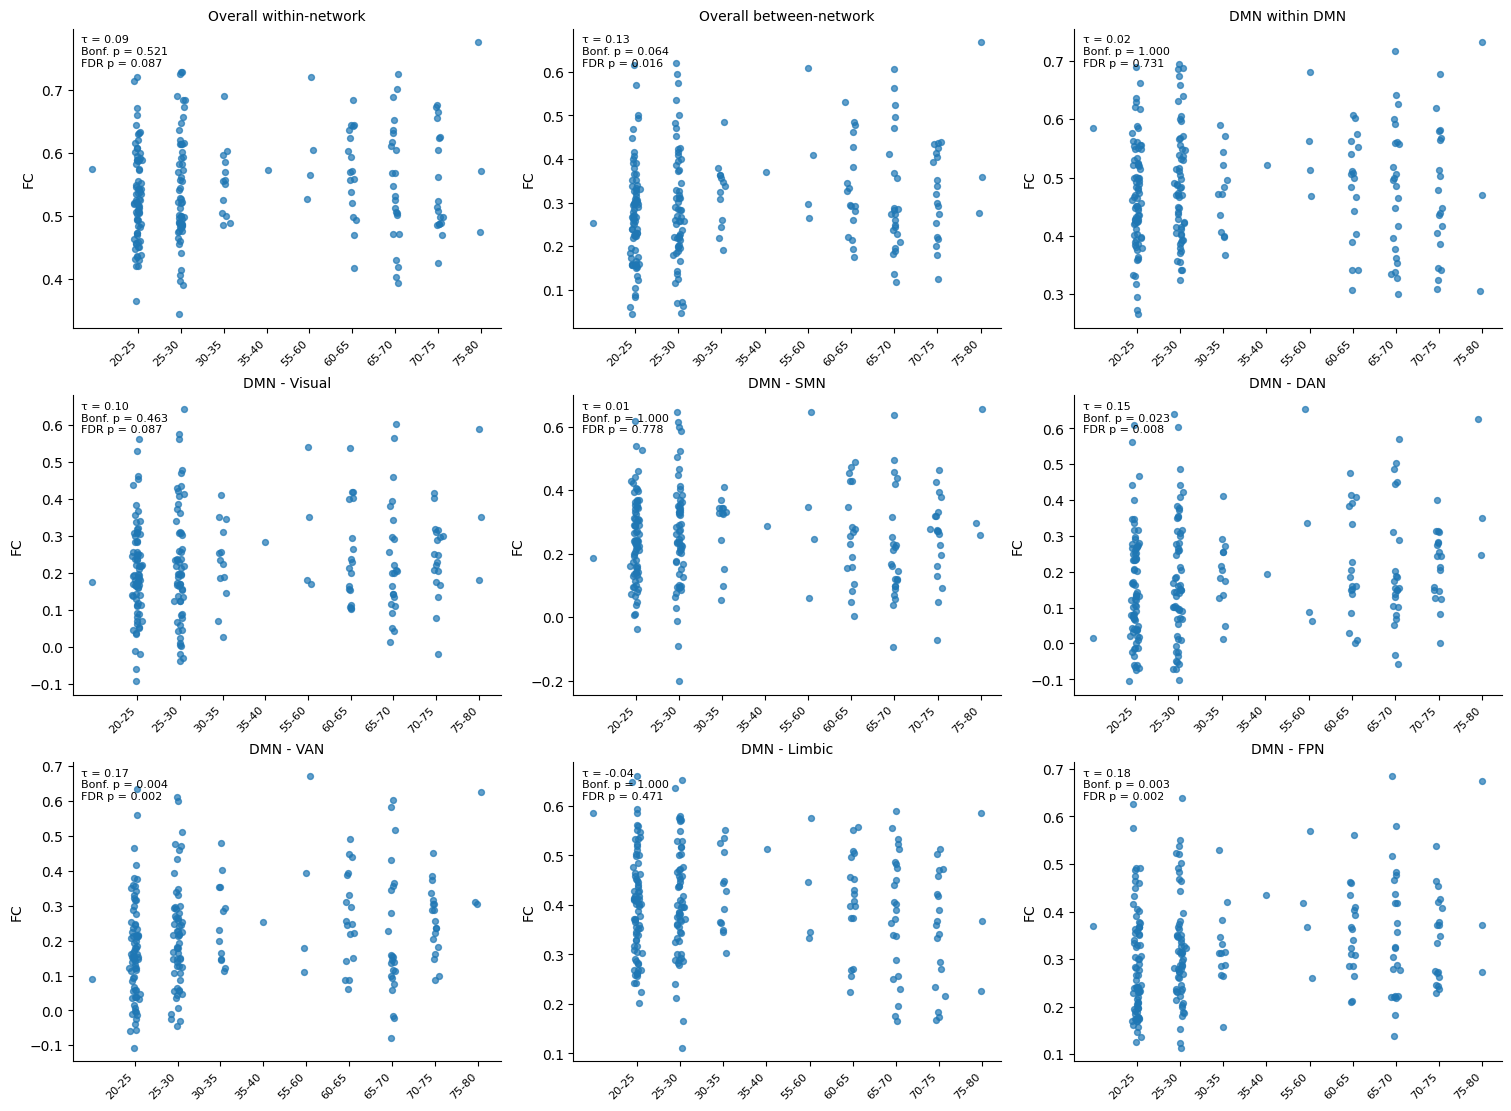

In [133]:
# ============================================================
# Plot 9 scatterplots: age bins vs FC
# ============================================================

# Make a lookup table for the correlation results
p_lookup = corr_results.set_index("measure")[["tau", "p_bonf", "p_fdr"]]

# Friendly labels for the plots
plot_labels = {
    "raw_within_all": "Overall within-network",
    "raw_between_all": "Overall between-network",
    "raw_DMN_DMN": "DMN within DMN",
    "raw_DMN_Visual": "DMN - Visual",
    "raw_DMN_SMN": "DMN - SMN",
    "raw_DMN_DAN": "DMN - DAN",
    "raw_DMN_VAN": "DMN - VAN",
    "raw_DMN_Limbic": "DMN - Limbic",
    "raw_DMN_FPN": "DMN - FPN",
}

fig, axes = plt.subplots(3, 3, figsize=(15, 11), constrained_layout=True)
axes = axes.ravel()

rng = np.random.default_rng(42)

for ax, col in zip(axes, corr_cols):
    tmp = corr_df[["age_code", col]].dropna()

    # Add a tiny amount of horizontal jitter
    x = tmp["age_code"].to_numpy() + rng.normal(0, 0.05, size=len(tmp))
    y = tmp[col].to_numpy()

    ax.scatter(x, y, s=18, alpha=0.7)

    # Axis labels
    ax.set_xticks(range(len(age_bins)))
    ax.set_xticklabels(age_bins, rotation=45, ha="right", fontsize=8)
    ax.set_title(plot_labels[col], fontsize=10)
    ax.set_ylabel("FC")

    # Show tau and corrected p-values
    tau = p_lookup.loc[col, "tau"]
    p_bonf = p_lookup.loc[col, "p_bonf"]
    p_fdr = p_lookup.loc[col, "p_fdr"]

    ax.text(
        0.02, 0.98,
        f"τ = {tau:.2f}\nBonf. p = {p_bonf:.3f}\nFDR p = {p_fdr:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.show()

# Linear Regression: Age and Functional Connectivity

In the previous section, we used **correlation** to ask a simple question:

> **Is functional connectivity associated with age?**

Correlation is an excellent tool for identifying whether two variables tend to vary together. However, it has some limitations. For example, it does not estimate **how much** functional connectivity changes with age, nor can it easily be extended to include additional variables such as sex, education, or depression scores.

To answer these kinds of questions, we use **linear regression**.

Linear regression fits a straight line that best describes the relationship between a predictor variable (here, **age**) and an outcome variable (here, **functional connectivity**).

Conceptually, the model can be written as:

> **Functional Connectivity = Intercept + (Slope × Age)**

The slope tells us how much functional connectivity is expected to change as we move from one age bin to the next.

Notice that simple linear regression still asks a very similar scientific question to correlation:

> **Does functional connectivity change with age?**

However, regression provides much more information than a correlation coefficient alone.

For each connectivity measure, the regression model estimates:

- **B**: the unstandardized regression coefficient (slope), indicating how much functional connectivity changes for each increase in age bin.
- **SE**: the standard error of the slope, describing the uncertainty of the estimate.
- **β**: the standardized regression coefficient, allowing us to compare the strength of the relationship across different predictors that are measured on different scales. (For example, if you later include Age, Education, and Sex in the same model, β lets you compare which predictor has the strongest association with connectivity, even though they are measured in different units.)
- **t** and **p**: statistical tests of whether the estimated slope is significantly different from zero.
- **R²**: the proportion of variability in functional connectivity that can be explained by age.

In this section, we will fit a **separate simple linear regression model** for each of our nine functional connectivity measures.

Although these models contain only one predictor (age), they introduce the same statistical framework that we will later extend to **multiple linear regression** and **moderation analysis**.

In [134]:
# ============================================================
# Linear regression for all connectivity measures
# ============================================================


# ------------------------------------------------------------
# Make sure age_bin is ordered and numeric
# ------------------------------------------------------------
reg_df = corr_df.copy()

# ------------------------------------------------------------
# Measures to test
# ------------------------------------------------------------
reg_cols = [
    "raw_within_all",
    "raw_between_all",
    "raw_DMN_DMN",
    "raw_DMN_Visual",
    "raw_DMN_SMN",
    "raw_DMN_DAN",
    "raw_DMN_VAN",
    "raw_DMN_Limbic",
    "raw_DMN_FPN",
]

# Friendly labels for output / plotting
reg_labels = {
    "raw_within_all": "Overall within-network",
    "raw_between_all": "Overall between-network",
    "raw_DMN_DMN": "DMN within DMN",
    "raw_DMN_Visual": "DMN - Visual",
    "raw_DMN_SMN": "DMN - SMN",
    "raw_DMN_DAN": "DMN - DAN",
    "raw_DMN_VAN": "DMN - VAN",
    "raw_DMN_Limbic": "DMN - Limbic",
    "raw_DMN_FPN": "DMN - FPN",
}

results = []

for col in reg_cols:
    tmp = reg_df[["age_code", col]].dropna()

    x = tmp["age_code"].to_numpy()
    y = tmp[col].to_numpy()

    # --------------------------------------------------------
    # Standardize x and y for standardized beta
    # --------------------------------------------------------
    x_z = (x - x.mean()) / x.std(ddof=1)
    y_z = (y - y.mean()) / y.std(ddof=1)

    # --------------------------------------------------------
    # Fit simple linear regression: y ~ age_code
    # --------------------------------------------------------
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    # Standardized regression: z(y) ~ z(x)
    X_z = sm.add_constant(x_z)
    model_z = sm.OLS(y_z, X_z).fit()

    # Store results
    results.append({
        "measure": col,
        "label": reg_labels[col],
        "B": model.params[1],
        "SE": model.bse[1],
        "beta": model_z.params[1],
        "t": model.tvalues[1],
        "p_raw": model.pvalues[1],
        "ci_low": model.conf_int()[1, 0],
        "ci_high": model.conf_int()[1, 1],
        "R2": model.rsquared,
        "adj_R2": model.rsquared_adj
    })

reg_results = pd.DataFrame(results)

# Multiple-comparison correction across the 9 regressions
reg_results["p_bonf"] = multipletests(reg_results["p_raw"], method="bonferroni")[1]
reg_results["p_fdr"] = multipletests(reg_results["p_raw"], method="fdr_bh")[1]

# Print a clean table
pd.set_option("display.max_columns", None)
display(reg_results.sort_values("p_raw"))

,measure,label,B,SE,beta,t,p_raw,ci_low,ci_high,R2,adj_R2,p_bonf,p_fdr
8,raw_DMN_FPN,DMN - FPN,0.009710,0.002866,0.223660,3.388130,0.000835,0.004062,0.015358,5.002377e-02,0.045666,0.007515,0.007515
6,raw_DMN_VAN,DMN - VAN,0.011974,0.003813,0.208026,3.140162,0.001922,0.004458,0.019489,4.327477e-02,0.038886,0.017302,0.008651
5,raw_DMN_DAN,DMN - DAN,0.011462,0.003980,0.191420,2.879523,0.004380,0.003617,0.019307,3.664145e-02,0.032222,0.039417,0.013139
1,raw_between_all,Overall between-network,0.008553,0.003080,0.184819,2.776659,0.005970,0.002482,0.014623,3.415817e-02,0.029728,0.053730,0.013433
3,raw_DMN_Visual,DMN - Visual,0.007144,0.003543,0.135296,2.016164,0.045010,0.000160,0.014127,1.830508e-02,0.013802,0.405089,0.069016
0,raw_within_all,Overall within-network,0.004120,0.002053,0.134676,2.006755,0.046011,0.000074,0.008167,1.813772e-02,0.013634,0.414098,0.069016
7,raw_DMN_Limbic,DMN - Limbic,-0.004821,0.002824,-0.114855,-1.707109,0.089226,-0.010386,0.000745,1.319163e-02,0.008665,0.803031,0.114719
2,raw_DMN_DMN,DMN within DMN,0.000727,0.002492,0.019742,0.291546,0.770911,-0.004185,0.005638,3.897528e-04,-0.004196,1.000000,0.867275
4,raw_DMN_SMN,DMN - SMN,0.000055,0.003875,0.000962,0.014204,0.988680,-0.007582,0.007692,9.254831e-07,-0.004586,1.000000,0.988680


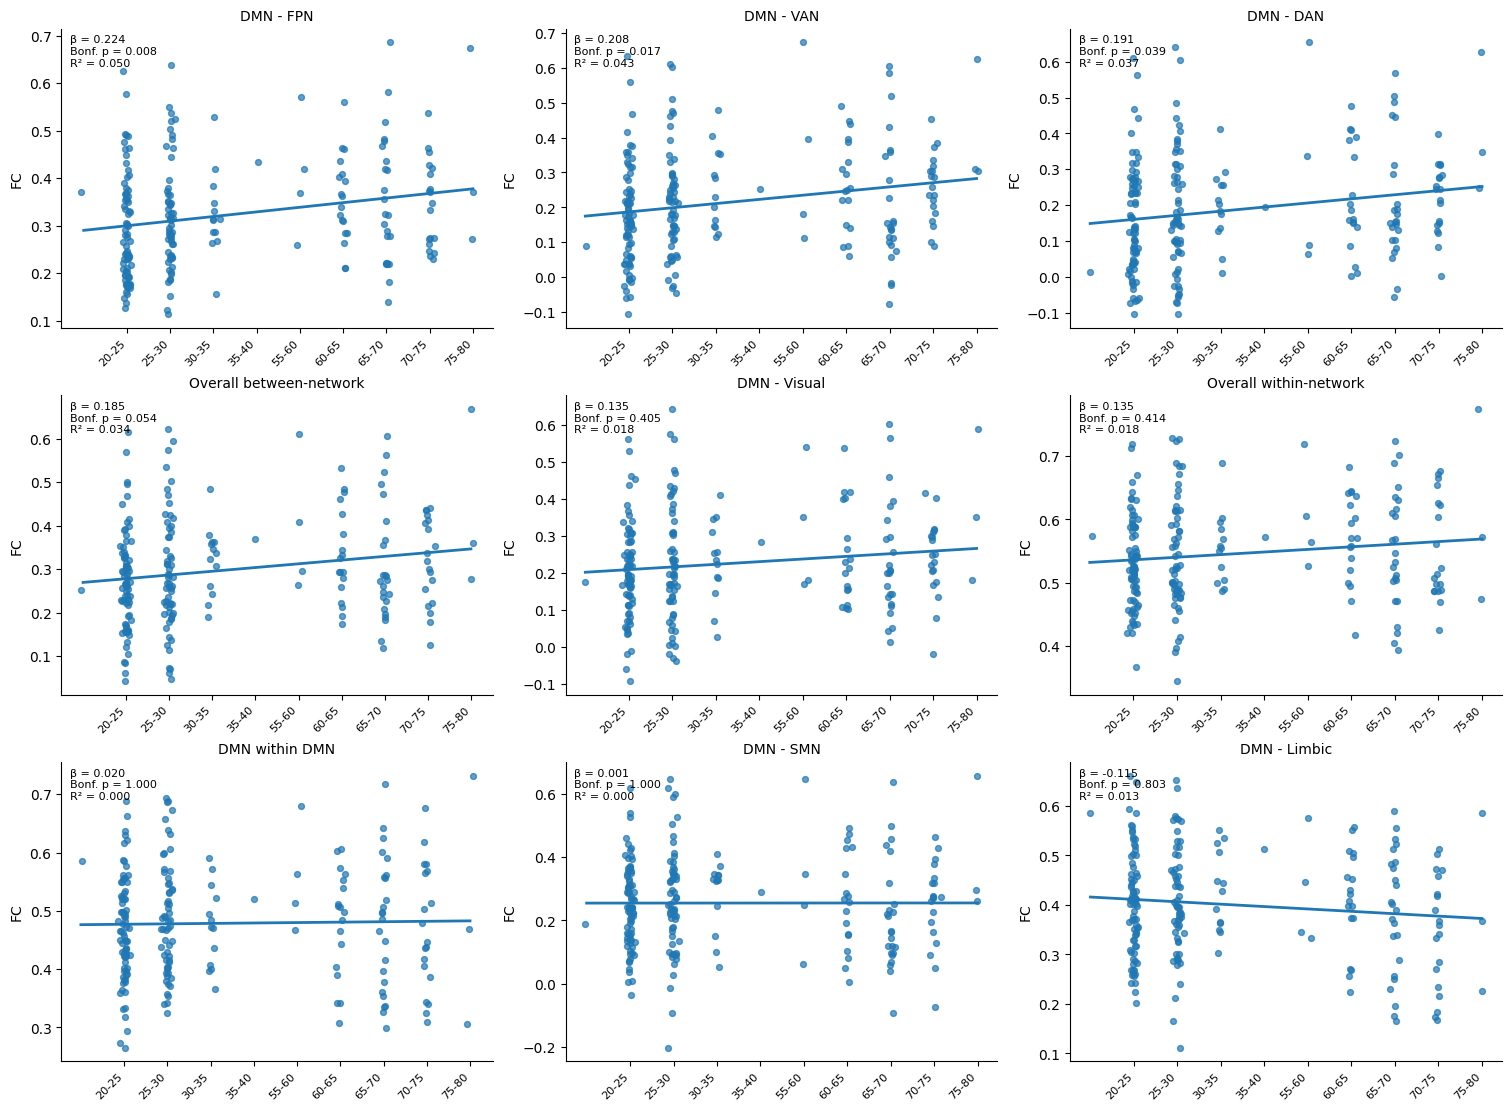

In [135]:
# ============================================================
# Plot all 9 regressions, ordered by beta (descending)
# ============================================================

# Sort measures by beta from highest to lowest
plot_order = (
    reg_results.sort_values("beta", ascending=False)["measure"]
    .tolist()
)

# Make a quick lookup table for the formatted values
plot_lookup = reg_results.set_index("measure")

fig, axes = plt.subplots(3, 3, figsize=(15, 11), constrained_layout=True)
axes = axes.ravel()

rng = np.random.default_rng(42)

for ax, col in zip(axes, plot_order):
    tmp = reg_df[["age_code", col]].dropna()

    x = tmp["age_code"].to_numpy()
    y = tmp[col].to_numpy()

    # Add a little jitter so points are easier to see
    x_jitter = x + rng.normal(0, 0.05, size=len(x))

    # Fit linear model for the line
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = model.params[0] + model.params[1] * x_line

    # Scatter plot
    ax.scatter(x_jitter, y, s=18, alpha=0.7)

    # Regression line
    ax.plot(x_line, y_line, linewidth=2)

    ax.set_xticks(range(len(age_bins)))
    ax.set_xticklabels(age_bins, rotation=45, ha="right", fontsize=8)
    ax.set_title(reg_labels[col], fontsize=10)
    ax.set_ylabel("FC")

    # Use beta, Bonferroni p-value, and R^2 in the panel text
    beta = plot_lookup.loc[col, "beta"]
    p_bonf = plot_lookup.loc[col, "p_bonf"]
    r2 = plot_lookup.loc[col, "R2"]

    ax.text(
        0.02, 0.98,
        f"β = {beta:.3f}\nBonf. p = {p_bonf:.3f}\nR² = {r2:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.show()

## Interpreting the Linear Regression Results

Before looking at the plots, let's first learn how to interpret the regression table.

For each connectivity measure, there are two quantities that are particularly useful:

- **β (beta)** tells us the **direction and strength** of the relationship.
- **p-value** tells us whether there is enough statistical evidence to conclude that the relationship is unlikely to have occurred by chance.

### Interpreting β (beta)

The sign of **β** tells us the direction of the relationship.

- A **positive β** means that connectivity tends to **increase** as age increases.
- A **negative β** means that connectivity tends to **decrease** as age increases.
- A **β close to zero** suggests little or no relationship.

The magnitude of **β** tells us how strong the relationship is. Larger values (in absolute value) indicate a stronger association between age and connectivity.

### Interpreting the p-value

The p-value tells us whether the observed relationship is statistically significant.

In this tutorial, we corrected the p-values using the **Bonferroni correction** because we tested nine different connectivity measures.

As a general guide:

- **Bonferroni-adjusted p < 0.05** suggests evidence for an association.
- **Bonferroni-adjusted p ≥ 0.05** suggests that the observed relationship could plausibly have occurred by chance.

With this in mind, we can now examine the regression plots.

The first thing to notice is that **most of the regression lines slope slightly upwards** (with the exception of DMN–Limbic). This means that, across many of these connectivity measures, functional connectivity tends to increase as we move from younger to older age groups.

However, not all of these increases are equally convincing.

The strongest positive relationships are seen for:

- **DMN–FPN connectivity** (β = 0.224, Bonferroni-adjusted *p* = 0.008),
- **DMN–VAN connectivity** (β = 0.208, Bonferroni-adjusted *p* = 0.017),
- **DMN–DAN connectivity** (β = 0.191, Bonferroni-adjusted *p* = 0.039).

Notice that these three plots have the steepest positive slopes, and they are also the only connectivity measures that remain statistically significant after correcting for multiple comparisons.

This is interesting because these are all **higher-order association networks**, involved in functions such as attention, executive function, and cognitive control. In this dataset, they appear to become more strongly connected with the Default Mode Network as age increases.

Now compare these with the **DMN within DMN** plot.

Here, the regression line is almost completely flat (β ≈ 0.02, *p* = 1.00 after Bonferroni correction). This suggests that connectivity **within the Default Mode Network itself** does not systematically change across the age groups represented in this dataset.

Similarly, **DMN–SMN** connectivity show little evidence of an age-related relationship.

## Summary

So far, these analyses paint a consistent picture: connectivity between the **DMN and several higher-order association networks** tends to increase across the age groups represented in the LEMON dataset.

However, there is still an important limitation.

So far, every model has considered **only one predictor: age**.

But participants differ in many other ways besides age. They also differ in sex, education, depression scores, alcohol use, relationship status, and many other behavioural or demographic characteristics.

This naturally leads to our next question:

> **Does age still predict functional connectivity after accounting for these other participant characteristics?**

To answer that question, we now extend simple linear regression to **multiple linear regression**, where several predictors can be included in the same statistical model.👇

# Multiple Linear Regression: Controlling for Additional Variables

In the previous section, we used **simple linear regression** to investigate whether functional connectivity changed with age.

Our model contained **one predictor**:

- **Predictor:** Age
- **Outcome:** DMN–FPN connectivity

Mathematically, a simple linear regression model can be written as:

$$
\text{Connectivity}
=
\beta_0
+
\beta_1(\text{Age})
+
\varepsilon
$$

where:

- **β₀** is the intercept (the predicted connectivity when Age = 0),
- **β₁** is the regression coefficient (or slope) for age,
- **ε** represents the remaining unexplained variation.

This equation simply says that we are trying to explain functional connectivity using **one predictor: age**.

In statistical software such as Python or R, the same model is often written using a shorthand formula notation:

```text
DMN–FPN connectivity ~ Age
```

The symbol **`~`** can be read as:

> **"is modelled as a function of"**

or simply

> **"is predicted by"**

So,

```text
DMN–FPN connectivity ~ Age
```

can be read as:

> **DMN–FPN connectivity is modelled as a function of age.**

---

## Why do we need multiple linear regression?

Our simple regression showed that connectivity between the **DMN–FPN**, **DMN–VAN**, and **DMN–DAN** increased with age, with standardized regression coefficients of approximately β ≈ 0.20, and these relationships (but not others) remained statistically significant after correcting for multiple comparisons.

However, age is unlikely to be the only factor influencing brain connectivity.

Participants also differ in many other characteristics, including:

- sex,
- education,
- depression score,
- alcohol consumption,
- relationship status,
- handedness.

These variables may also contribute to differences in functional connectivity.

This naturally raises a new question:

> **Does age still predict functional connectivity (e.g., DMN-FPN) after accounting for these other participant characteristics?**

To answer this, we extend our model by including **multiple predictors**.

Instead of modelling connectivity using only age,

```text
DMN–FPN connectivity ~ Age
```

we now fit the model

```text
DMN–FPN connectivity
~
Age
+
Sex
+
Education
+
Hamilton Scale (depression scores)
+
AUDIT (alcohol use disorder test scores)
+
Relationship Status
```

Mathematically, this becomes

$$
\begin{aligned}
\text{Connectivity}
=
&\;
\beta_0
+
\beta_1(\text{Age})
+
\beta_2(\text{Sex})
+
\beta_3(\text{Education}) \\
&
+
\beta_4(\text{Hamilton})
+
\beta_5(\text{AUDIT})
+
\beta_6(\text{Relationship})
+
\varepsilon
\end{aligned}
$$

Each predictor has its own regression coefficient (**β**), allowing the model to estimate the contribution of each variable while accounting for all the others.

For example, the coefficient for **Age (β0)** now answers the question:

> *If two participants have the same sex, education, Hamilton score, AUDIT score, relationship status, and handedness, does the older participant still tend to have higher DMN–FPN connectivity?*

The participant information used in this model such as relationship status comes from the cleaned metadata table (`analysis_meta`), which was previously saved as **`lemon_analysis_metadata.csv`**.

## Coding: Steps

Before fitting the regression model, we need to prepare the data.

We will:

- merge the participant metadata with the FC summary measures,
- remove participants with missing values in any of the variables used in the model,
- convert categorical variables (e.g., sex and education) into numeric variables that the regression model can use,
- fit a multiple linear regression predicting **DMN–FPN connectivity**,
- examine the regression coefficients, confidence intervals, and statistical significance of each predictor.

In [ ]:
# ============================================================
# Prepare data for multiple linear regression
# ============================================================

# ------------------------------------------------------------
# Merge FC summary with metadata
# ------------------------------------------------------------
meta_cols = [
    "subject_id",
    "sex",
    "education",
    "Hamilton_Scale",
    "AUDIT",
    "Relationship_Status",
]

reg_df = corr_df.merge(
    analysis_meta[meta_cols],
    on="subject_id",
    how="inner"
).copy()

# ------------------------------------------------------------
# Clean the variables we will use in the model
# ------------------------------------------------------------

# Make sure numeric columns are numeric
reg_df["Hamilton_Scale"] = pd.to_numeric(reg_df["Hamilton_Scale"], errors="coerce")
reg_df["AUDIT"] = pd.to_numeric(reg_df["AUDIT"], errors="coerce")

# Sex: female = 0, male = 1
reg_df["sex"] = (
    reg_df["sex"]
    .astype(str)
    .str.lower()
    .str.strip()
    .map({"female": 0, "male": 1})
)

# Education: Realschule = 0, Gymnasium = 1
reg_df["education"] = (
    reg_df["education"]
    .astype(str)
    .str.strip()
    .map({"Realschule": 0, "Gymnasium": 1})
)

# Relationship: No = 0, Yes = 1
reg_df["Relationship_Status"] = (
    reg_df["Relationship_Status"]
    .astype(str)
    .str.strip()
    .str.title()
    .map({"No": 0, "Yes": 1})
)


# ------------------------------------------------------------
# Count how many Young/Old subjects we have before removing missing data
# ------------------------------------------------------------
before_counts = reg_df["age_group"].value_counts()

# Remove subjects with missing values in any model variable
reg_df = reg_df.dropna(
    subset=[
        "age_bin",
        "sex",
        "education",
        "Hamilton_Scale",
        "AUDIT",
        "Relationship_Status",
        "raw_DMN_FPN",
    ]
).copy()

# Count again after removing missing data
after_counts = reg_df["age_group"].value_counts()

print("Subjects removed because of missing data")
print("----------------------------------------")
for group in ["Young", "Old"]:
    removed = before_counts.get(group, 0) - after_counts.get(group, 0)
    print(f"{group}: {removed}")

reg_df["Age"] = reg_df["age_code"]


Subjects removed because of missing data
----------------------------------------
Young: 11
Old: 7


In [ ]:
# ============================================================
# Multiple linear regression: DMN-FPN connectivity
# ============================================================

# ------------------------------------------------------------
# Final predictor list
# ------------------------------------------------------------
predictor_cols = [
    "Age",
    "sex",
    "education",
    "Hamilton_Scale",
    "AUDIT",
    "Relationship_Status",
]

# Outcome variable
y = reg_df["raw_DMN_FPN"]

# Predictors
X = sm.add_constant(reg_df[predictor_cols])

# Fit ordinary least squares model
model = sm.OLS(y, X).fit()

# Standardized regression: z(y) ~ z(x)
X_z = reg_df[predictor_cols].copy()
X_z = (X_z - X_z.mean()) / X_z.std(ddof=1)

y_z = (y - y.mean()) / y.std(ddof=1)

X_z = sm.add_constant(X_z)
model_z = sm.OLS(y_z, X_z).fit()

# ------------------------------------------------------------
# Create a clean results table
# ------------------------------------------------------------
ci = model.conf_int()

results = pd.DataFrame({
    "Predictor": predictor_cols,
    "B": model.params[predictor_cols].values,
    "SE": model.bse[predictor_cols].values,
    "beta": model_z.params[predictor_cols].values,
    "t": model.tvalues[predictor_cols].values,
    "p": model.pvalues[predictor_cols].values,
    "CI lower": ci.loc[predictor_cols, 0].values,
    "CI upper": ci.loc[predictor_cols, 1].values,
})

display(results)

print(f"\nR² = {model.rsquared:.3f}")
print(f"Adjusted R² = {model.rsquared_adj:.3f}")

,Predictor,B,SE,beta,t,p,CI lower,CI upper
0,Age,0.010624,0.003701,0.242699,2.870897,0.004548,0.003326,0.017923
1,sex,0.018577,0.017459,0.078663,1.064023,0.288641,-0.015857,0.053010
2,education,0.024217,0.023091,0.085711,1.048758,0.295594,-0.021325,0.069759
3,Hamilton_Scale,0.004305,0.003042,0.100344,1.415236,0.158603,-0.001695,0.010305
4,AUDIT,-0.003105,0.002199,-0.106957,-1.411780,0.159617,-0.007443,0.001233
5,Relationship_Status,0.009762,0.017220,0.040870,0.566917,0.571426,-0.024200,0.043725



R² = 0.075
Adjusted R² = 0.046


## Interpreting the Multiple Linear Regression

### Does age remain a significant predictor?

Recall that in the previous section, we found that **DMN–FPN connectivity increased with age** using a simple linear regression.

Here, we extended the model by including several additional variables such as sex, education, depression scores, scores from alcohol use disorders identification test (AUDIT), and relationship status. 

This allows us to ask a more specific question:

> **Does age still predict DMN–FPN connectivity after accounting for these other participant characteristics?**

Here, based on the results, age remains a significant predictor! 

The regression coefficient for **Age** remained statistically significant:

- **B = 0.0106**
- **β = 0.243**
- **p = 0.0045**
- **95% CI = [0.0033, 0.0179]**

What does this mean?

Imagine comparing two participants who have the **same sex, education level, Hamilton score, AUDIT score, and relationship status**, but differ in age. The model estimates that the participant in the older age bin is expected to have, on average, **higher DMN–FPN connectivity**.

This is what is meant by controlling for the other variables. In this analysis, variables such as sex, education, depression score, alcohol use, and relationship status are treated as covariates. Remember, in our research question, we are primarily interested in AGING, which is the main variable of interest. Therefore, variables that are not the main focus of the research question are called "covariates". By including them in the regression model, we account for their potential influence, allowing us to estimate the relationship between age and DMN–FPN connectivity more accurately.

Notice that the standardized regression coefficient (**β = 0.243**) is very similar to the value obtained in the simple linear regression (**β ≈ 0.224**). This suggests that the relationship between age and DMN–FPN connectivity is **not explained** by differences in sex, education, mood, alcohol use, or relationship status. Instead, age appears to have its own independent association with DMN–FPN connectivity in this dataset.


### The other variables were not statistically significant**

The remaining predictors all had **p-values greater than 0.05**, indicating that they were not significantly associated with DMN–FPN connectivity in this model.

For example:

- Sex: *p* = 0.289
- Education: *p* = 0.296
- Hamilton Scale: *p* = 0.159
- AUDIT: *p* = 0.160
- Relationship Status: *p* = 0.571

This does **not** necessarily mean these variables have no relationship with brain connectivity. Rather, in this sample and for this particular model, there was not enough evidence to conclude that they explained additional variation in DMN–FPN connectivity beyond age.


### Why do we care about explaining variation?

Every participant has a slightly different level of DMN–FPN connectivity. This natural spread in the data is called **variation**.

The goal of regression is to understand **why** this variation exists.

For example, some of the variation might be explained by:

- age,
- education,
- mood,
- alcohol use,
- or other biological and environmental factors.

A useful regression model explains as much of this variation as possible. The more variation we can explain, the better we understand which factors are associated with differences in brain connectivity.

The model explained approximately **7.5%** of the variation in DMN–FPN connectivity (**R² = 0.075**). This means that the predictors included in the model collectively accounted for about 7.5% of the differences in DMN–FPN connectivity across participants.

After accounting for the number of predictors in the model, the **adjusted R²** was **0.046**, meaning that approximately **4.6%** of the variation remained explained after penalizing the model for its complexity.

Although these values are relatively modest, this is common in neuroscience. Brain connectivity is influenced by many genetic, biological, behavioural, environmental, and measurement-related factors that are not included in a single regression model. Therefore, even models with relatively small R² values can still reveal meaningful relationships. At the same time, one goal of neuroscience research is to better explain more of the variation in our brain. This may involve including or collecting additional variables, such as cognitive performance, genetic factors, lifestyle, or other brain imaging measures, that help us better understand why individuals differ from one another. 

Overall, these results suggest that **age remains an independent predictor of DMN–FPN connectivity**, even after accounting for several demographic and behavioural covariates.

> Although we've explained about 4.6% of the variation, what other factors might explain the remaining 95.4%?


# Moderation Analysis

So far, we have found that **DMN–FPN connectivity tends to increase with age**, even after accounting for several participant characteristics using multiple linear regression.

As neuroscientists, however, we might wonder whether this tells the whole story.

The **Default Mode Network (DMN)** and the **Frontoparietal Network (FPN)** have both been implicated in healthy aging, but they have also been linked to depression and other psychiatric conditions. This raises an interesting biological question:

> **Could the relationship between age and DMN–FPN connectivity depend on a participant's level of depression?**

In other words, perhaps aging affects DMN–FPN connectivity differently for people with low depression scores than for people with higher depression scores.

This type of question is called a **moderation analysis**.

---

## What is a moderation effect?

Imagine two participants who are the same age.

One has very low depression symptoms, while the other has much higher depression symptoms.

Would we expect aging to influence their brain connectivity in exactly the same way?

Perhaps not.

For example:

- among people with **low depression scores**, DMN–FPN connectivity might increase only slightly with age;
- among people with **high depression scores**, DMN–FPN connectivity might increase much more rapidly with age.

If this were true, we would say that **depression moderates the relationship between age and DMN–FPN connectivity**.

Rather than asking

> **Does age predict connectivity?**

we now ask a more specific question:

> **Does depression change or moderate the relationship between age and DMN–FPN connectivity?**

---

## Adding an interaction term

Previously, our multiple linear regression model included age and several covariates:

```text
DMN–FPN connectivity
~
Age
+
Sex
+
Education
+
Hamilton Scale
+
AUDIT
+
Relationship Status
```

To test for moderation, we keep all of these predictors **and add one extra term**:

```text
DMN–FPN connectivity
~
Age
+
Sex
+
Education
+
Hamilton Scale
+
AUDIT
+
Relationship Status
+
Age × Hamilton Scale
```

The new term,

```text
Age × Hamilton Scale
```

is called an **interaction term**.

It represents the possibility that the effect of age is **different** at different levels of depression.

Our research question therefore becomes:

> **After controlling for the same covariates as before, does depression score moderate the relationship between age and DMN–FPN connectivity?**

If the interaction term is statistically significant, it suggests that the relationship between age and connectivity depends on depression score.

If the interaction term is not statistically significant, then the relationship between age and connectivity is similar regardless of depression score.

Moderation analysis is widely used in neuroscience because many biological and behavioural relationships are unlikely to be the same for every participant. Instead, one factor may strengthen, weaken, or even reverse the influence of another.

In [138]:
predictor_cols

['Age', 'sex', 'education', 'Hamilton_Scale', 'AUDIT', 'Relationship_Status']

In [139]:
# ============================================================
# Moderation analysis:
# Does Hamilton Scale moderate the relationship between
# age and DMN-FPN connectivity?
# ============================================================

predictor_cols = [
    "Age",
    "sex",
    "education",
    "Hamilton_Scale",
    "AUDIT",
    "Relationship_Status",
]

# ------------------------------------------------------------
# Create the interaction term
# ------------------------------------------------------------
reg_df["Age_x_Hamilton"] = (
    reg_df["Age"] *
    reg_df["Hamilton_Scale"]
)

# Add the moderation (interaction) term
predictor_cols.append("Age_x_Hamilton")

# Outcome
y = reg_df["raw_DMN_FPN"]

# Design matrix
X = sm.add_constant(reg_df[predictor_cols].astype(float))

# ------------------------------------------------------------
# Fit the regression model
# ------------------------------------------------------------
model = sm.OLS(y, X).fit()

# ------------------------------------------------------------
# Standardized regression coefficients
# ------------------------------------------------------------
X_z = reg_df[predictor_cols].copy()
X_z = (X_z - X_z.mean()) / X_z.std(ddof=1)

y_z = (y - y.mean()) / y.std(ddof=1)

X_z = sm.add_constant(X_z)

model_z = sm.OLS(y_z, X_z).fit()

# ------------------------------------------------------------
# Create a clean results table
# ------------------------------------------------------------
ci = model.conf_int()

results = pd.DataFrame({
    "Predictor": predictor_cols,
    "B": model.params[predictor_cols].values,
    "SE": model.bse[predictor_cols].values,
    "beta": model_z.params[predictor_cols].values,
    "t": model.tvalues[predictor_cols].values,
    "p": model.pvalues[predictor_cols].values,
    "CI lower": ci.loc[predictor_cols, 0].values,
    "CI upper": ci.loc[predictor_cols, 1].values,
})

display(results)

print(f"\nR² = {model.rsquared:.3f}")
print(f"Adjusted R² = {model.rsquared_adj:.3f}")

,Predictor,B,SE,beta,t,p,CI lower,CI upper
0,Age,0.005396,0.004343,0.123260,1.242360,0.215611,-0.003170,0.013962
1,sex,0.020094,0.017294,0.085090,1.161927,0.246700,-0.014015,0.054204
2,education,0.030810,0.023044,0.109044,1.336982,0.182802,-0.014641,0.076260
3,Hamilton_Scale,-0.000926,0.003810,-0.021582,-0.243026,0.808243,-0.008441,0.006589
4,AUDIT,-0.003043,0.002177,-0.104834,-1.397905,0.163746,-0.007337,0.001251
5,Relationship_Status,0.014436,0.017171,0.060435,0.840684,0.401565,-0.019432,0.048303
6,Age_x_Hamilton,0.002616,0.001168,0.234940,2.240507,0.026198,0.000313,0.004919



R² = 0.098
Adjusted R² = 0.066


## Interpreting the Moderation Analysis

As a reminder, our research question was:

> **Does depression score moderate the relationship between age and DMN–FPN connectivity?**

To answer this, we fitted a multiple linear regression model that included:

- Age
- Sex
- Education
- Hamilton Scale (depression score)
- AUDIT
- Relationship Status
- **Age × Hamilton Scale** (interaction term)

### Is the interaction significant?

The first thing we should look at is the **interaction term**, since this directly tests our research question.

The interaction between **Age** and **Hamilton Scale** was statistically significant (p < 0.05):

- **B = 0.0026**
- **β = 0.235**
- **p = 0.026**
- **95% CI = [0.0003, 0.0049]**

This tells us that the relationship between age and DMN–FPN connectivity **changes depending on a participant's depression score**.

Interestingly, neither **Age** (*p* = 0.216) nor **Hamilton Scale** (*p* = 0.808) was statistically significant on its own.

This may seem surprising at first, but remember that moderation asks a different question.

Instead of asking:

> **Does age predict connectivity?**

or

> **Does depression predict connectivity?**

we are asking:

> **Does depression change how age is related to connectivity?**

A significant interaction suggests that the answer is **yes**.

One possible interpretation is that the positive relationship between age and DMN–FPN connectivity is **stronger for participants with higher depression scores** than for those with lower depression scores.

Notice that this does **not** mean depression itself increases or decreases connectivity. Instead, it suggests that depression changes **how strongly age is associated with connectivity**.

### Do we need multiple-comparison correction?

You may notice that the regression output reports a p-value for every predictor in the model.

However, not every coefficient necessarily represents a separate scientific hypothesis.

In this analysis, our primary hypothesis concerns the **Age × Hamilton Scale interaction**. The remaining variables (sex, education, AUDIT, relationship status, etc.) are included as **covariates** to account for potential confounding influences.

Because the interaction term is our single **pre-specified hypothesis**, many neuroscience studies would report its uncorrected p-value.

If, instead, we were testing many different interaction terms or fitting many regression models, then multiple-comparison correction (for example, Bonferroni or False Discovery Rate correction) would become appropriate.

---

## Visualizing the interaction

The regression table tells us that the interaction is statistically significant, but it does not show us **what that interaction actually looks like**.

To better understand the result, we can visualize the data.

Let's divide participants into three groups based on their Hamilton depression scores:

- **Low**
- **Medium**
- **High**

For each group, we plotted DMN–FPN connectivity against age and fitted a separate regression line.

Notice that this is **not another statistical test**. Instead, it provides an intuitive way to visualize the interaction estimated by the regression model and helps us answer questions such as:

- Does the relationship between age and DMN–FPN connectivity become stronger as depression scores increase?
- Are the regression slopes noticeably different across the three depression groups?

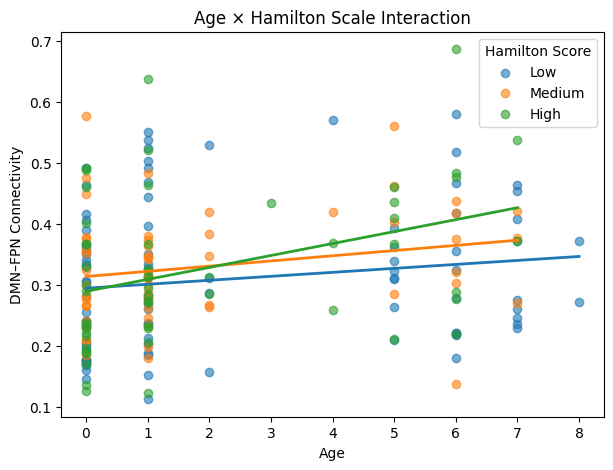

In [ ]:
# ------------------------------------------------------------
# Create depression groups
# ------------------------------------------------------------
reg_df["Hamilton_group"] = pd.qcut(
    reg_df["Hamilton_Scale"],
    q=3,
    labels=["Low", "Medium", "High"]
)

fig, ax = plt.subplots(figsize=(7, 5))

for group in ["Low", "Medium", "High"]:

    subset = reg_df[reg_df["Hamilton_group"] == group]

    # --------------------------------------------------------
    # Scatter plot
    # --------------------------------------------------------
    ax.scatter(
        subset["Age"],
        subset["raw_DMN_FPN"],
        alpha=0.6,
        label=group
    )

    # --------------------------------------------------------
    # Fit simple linear regression using statsmodels
    # --------------------------------------------------------
    X = sm.add_constant(subset["Age"])
    y = subset["raw_DMN_FPN"]

    model = sm.OLS(y, X).fit()

    # --------------------------------------------------------
    # Predicted regression line
    # --------------------------------------------------------
    x = np.linspace(
        subset["Age"].min(),
        subset["Age"].max(),
        100
    ) # generate 100 `x` values (age)

    X_pred = sm.add_constant(x)
    y_pred = model.predict(X_pred) # generate predicted y values based on the regression equation

    ax.plot(x, y_pred, linewidth=2)

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xlabel("Age")
ax.set_ylabel("DMN–FPN Connectivity")
ax.set_title("Age × Hamilton Scale Interaction")

ax.legend(title="Hamilton Score")

plt.show()

## Interpreting the interaction plot

The figure provides a visual illustration of the moderation effect.

Several observations stand out.

First, participants with **higher Hamilton scores** (green line) appear to show the steepest increase in DMN–FPN connectivity with age.

In contrast, participants with **lower Hamilton scores** (blue line) show only a relatively small increase in connectivity across the age range.

The **medium** depression group lies between these two extremes.

These different slopes are exactly what we would expect from a significant interaction term. They suggest that the relationship between age and DMN–FPN connectivity is **not constant across all participants**, but instead varies according to depression score.

Importantly, this figure should be interpreted as a visualization of the fitted regression model rather than definitive proof on its own. The statistical evidence for the interaction comes from the regression coefficient for the **Age × Hamilton Scale** term (*p* = 0.026). The figure simply helps us understand what that significant interaction means in practice.

One possible interpretation is that **age-related increases in DMN–FPN connectivity are more pronounced among participants with higher depression scores** than among those with lower depression scores.

## Quantifying the slopes

The interaction plot suggests that the slope relating age to DMN–FPN connectivity differs across depression groups.

Rather than relying on visual inspection alone, we can quantify these slopes directly.

For each Hamilton group (Low, Medium, and High), we will fit a simple linear regression model:

> DMN–FPN connectivity ~ Age

This will allow us to estimate:

- the regression slope,
- its confidence interval,
- and the statistical significance of the age effect within each depression group.

Comparing these slopes provides a simple way of understanding how the age–connectivity relationship changes across different levels of depression symptoms.

In [141]:
# ============================================================
# Estimate age slopes within each Hamilton group
# ============================================================

slope_results = []

for group in ["Low", "Medium", "High"]:

    subset = reg_df[reg_df["Hamilton_group"] == group]

    y = subset["raw_DMN_FPN"]
    X = sm.add_constant(subset["Age"])

    model = sm.OLS(y, X).fit()

    ci = model.conf_int().loc["Age"]

    slope_results.append({
        "Hamilton group": group,
        "Slope (B)": model.params["Age"],
        "SE": model.bse["Age"],
        "t": model.tvalues["Age"],
        "p": model.pvalues["Age"],
        "95% CI lower": ci[0],
        "95% CI upper": ci[1],
        "R²": model.rsquared,
    })

slope_df = pd.DataFrame(slope_results)

display(slope_df)

,Hamilton group,Slope (B),SE,t,p,95% CI lower,95% CI upper,R²
0,Low,0.006498,0.004278,1.518984,0.132233,-0.001999,0.014995,0.024728
1,Medium,0.008486,0.005234,1.621198,0.110910,-0.002013,0.018985,0.047247
2,High,0.019557,0.006915,2.828176,0.006675,0.005674,0.033440,0.135572


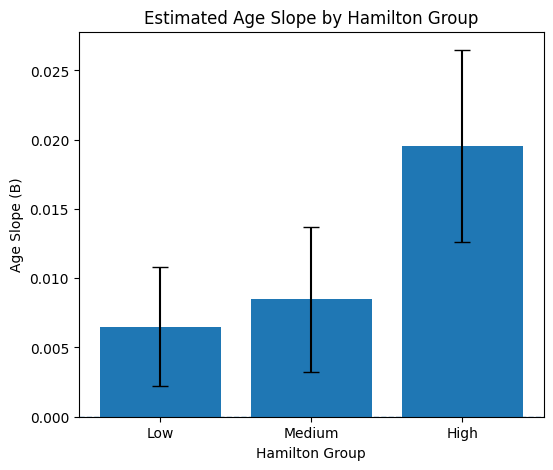

In [142]:
# ============================================================
# Plot age slopes for each Hamilton group
# ============================================================

fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(
    slope_df["Hamilton group"],
    slope_df["Slope (B)"],
    yerr=slope_df["SE"],
    capsize=6,
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xlabel("Hamilton Group")
ax.set_ylabel("Age Slope (B)")
ax.set_title("Estimated Age Slope by Hamilton Group")

plt.show()

## Interpreting the Slopes 

To better understand the significant interaction between **Age** and **Hamilton Scale**, we estimated the relationship between age and DMN–FPN connectivity separately for participants with **Low**, **Medium**, and **High** depression scores.

The results showed a clear pattern.

For participants with **low Hamilton scores**, there was a small positive relationship between age and DMN–FPN connectivity (**B = 0.0065**), but this relationship was **not statistically significant** (*p* = 0.132).

Similarly, for participants with **medium Hamilton scores**, the estimated slope was slightly larger (**B = 0.0085**), although it also did **not reach statistical significance** (*p* = 0.111).

In contrast, participants with **high Hamilton scores** showed a much steeper positive relationship between age and DMN–FPN connectivity (**B = 0.0196**), and this association was **statistically significant** (*p* = 0.0067).

These findings are consistent with the interaction observed in the multiple regression model. Specifically, they suggest that the positive association between age and DMN–FPN connectivity becomes stronger as depression scores increase.

Altogether, the moderation analysis and the follow-up subgroup analyses allowed us to learn something new about how depression scores may moderate the effect of aging on DMN-FPN interaction! 

# Tutorial Summary and Next Steps

Congratulations! By completing this tutorial, you have learned several of the most commonly used statistical approaches for studying relationships between the brain and behaviour.

In particular, you have learned how to:

- quantify associations using **correlation**,
- model relationships using **simple linear regression**,
- account for additional variables using **multiple linear regression**, and
- investigate interaction effects using **moderation analysis**.

These techniques form the foundation of a large proportion of modern neuroimaging research, and many neuroscience papers rely on these statistical concepts. 

---

## Building good research questions

One of the most important lessons from this tutorial is that **statistics should be driven by scientific questions, not the other way around.**

Before building a regression model, ask yourself:

- What am I trying to understand?
- Which variable is my main variable of interest?
- Which other variables might influence this relationship?
- Should these variables be treated as covariates?
- Is there a reason to believe that one variable may moderate another?

A good regression model is motivated by **theory**, previous literature, or a clearly defined hypothesis.

For example, if your research question is:

> **Does personality predict functional connectivity?**

then personality may be your **main predictor**, while age and sex may be included as **covariates** because they are known to influence both personality and brain connectivity.

On the other hand, if your research question is:

> **How does aging affect functional connectivity?**

then age becomes the main predictor, while personality may instead be treated as a covariate.

The same variable can therefore play different roles depending on the research question.

---

## Exploratory versus hypothesis-driven research

Not every analysis needs to begin with a strong hypothesis.

Sometimes researchers perform **exploratory analyses** to search for interesting patterns that may motivate future studies.

However, exploratory analyses require careful interpretation.

If we were to test hundreds or even thousands of possible relationships, some will inevitably appear statistically significant purely by chance.

This is why multiple-comparison correction methods, such as **Bonferroni correction** or **False Discovery Rate (FDR)** correction, become increasingly important when performing many statistical tests.

As neuroscientists, our goal is not simply to find statistically significant results. Instead, we aim to identify findings that are:

- biologically plausible,
- statistically robust,
- reproducible,
- and supported by previous evidence.

Developing this critical way of thinking is just as important as learning how to write the analysis code itself.

---

## A suggested exercise

Now that you understand the basic statistical workflow, try reading published neuroimaging papers and identify how they built their statistical models.

For example, Simon et al. (2020) investigated whether personality traits were associated with resting-state functional connectivity. They reported findings such as:

> "Openness was positively associated with connectivity in the default-mode network, neuroticism was negatively associated with both the ventral and dorsal attention networks, and agreeableness was negatively associated with the dorsal attention network."

In their statistical models, they first included **age** and **sex** as demographic variables before entering the personality measures.

Ask yourself:

- Which variables were the **main predictors**?
- Which variables were treated as **covariates**?
- Why might age and sex have been included?
- Can you interpret the regression coefficients reported in their Table 2?
- Can you understand their moderation analysis after completing this tutorial?

These are excellent exercises for developing your ability to critically read the scientific literature.

---

## Try your own research question

The LEMON dataset contains many behavioural and demographic measures beyond age.

Try investigating whether resting-state functional connectivity is associated with:

- personality traits,
- cognitive measures,
- depression or anxiety scores,
- lifestyle measures,
- education,
- handedness,
- physiological measurements,
- or any other phenotype available in the dataset.

Can you reproduce findings reported in previous publications?

Can you discover new hypotheses worth investigating?

---

## Continue learning

The statistical methods introduced here are only the beginning.

As you continue learning, you may wish to explore topics such as:

- the mathematical derivation of linear regression,
- mediation analysis,
- logistic regression,
- mixed-effects models,
- generalized linear models,
- structural equation modelling,
- Bayesian regression,
- and causal inference.

A deeper understanding of these methods will help you interpret scientific findings more critically and build more sophisticated models for your own research.

---

## Looking ahead

In this tutorial, we primarily used linear regression as a tool for **association analysis**. We asked questions such as:

> *Is functional connectivity associated with age?*

In the next tutorial, we will shift our focus from **association** to **prediction**.

Interestingly, the same linear regression model that we used here is also one of the **machine learning algorithms**. Instead of asking whether two variables are associated, we will ask whether brain connectivity can be used to **predict** behavioural or demographic measures in unseen participants.